In [29]:
# import the libraries
import cobra
import matplotlib.pyplot as plt
import scipy as sp
import numpy as np
import pandas as pd
from sklearn import decomposition
from sklearn import datasets
from sklearn.preprocessing import scale
from sklearn.linear_model import LinearRegression
import statsmodels
from scipy.stats import sem, t
from numpy import mean
from statsmodels.sandbox.stats.multicomp import multipletests
import seaborn as sns
from scipy.stats import hypergeom

In [35]:
# import FS files
samples_HC = pd.read_csv("/Users/apple/Downloads/Script_CBM_and_Analysis/4.Analysis/Flux_Sampling/model_con_h10vscd9.csv")
samples_T2D = pd.read_csv("/Users/apple/Downloads/Script_CBM_and_Analysis/4.Analysis/Flux_Sampling/modelCD_h10vscd9.csv")

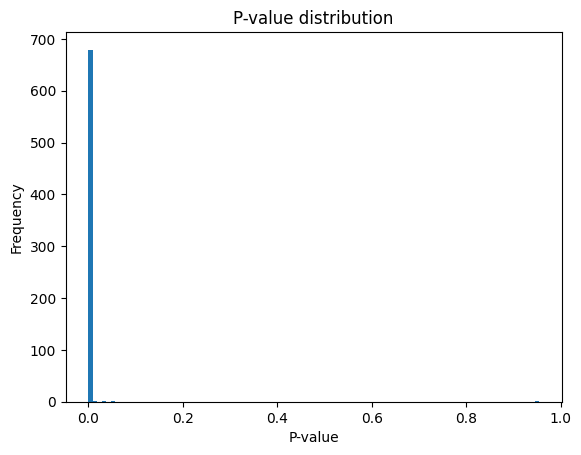

In [37]:
# differential flux analysis between control and t2d responder
def kstest(samplesUI,samplesI,file_name):

    rxns1=set(samplesUI.columns)
    rxns2=set(samplesI.columns)

    rxn_c=rxns1.intersection(rxns2)

    pvals=[]
    rxnid=[]
    fc=[]

    for rxn in rxn_c:
        data1=samplesUI[rxn].round(decimals=4)
        data2=samplesI[rxn].round(decimals=4)
        data1=data1.sample(n=1000)
        data2=data2.sample(n=1000)
        if((data1.std()!=0 and data1.mean()!=0) or (data2.std()!=0 and data2.mean()!=0)):
            kstat,pval=sp.stats.ks_2samp(data1,data2)
            foldc=(data1.mean()-data2.mean())/abs(data1.mean()+data2.mean())
            pvals.append(pval)
            rxnid.append(rxn)
            fc.append(foldc)
    data_mwu=pd.DataFrame({'Reaction':rxnid,'Pvalue':pvals})
    data_mwu=data_mwu.set_index('Reaction')
    plt.hist(data_mwu['Pvalue'],100)
    plt.xlabel('P-value')
    plt.ylabel('Frequency')
    plt.title('P-value distribution')
    reject,padj,_,_=statsmodels.stats.multitest.multipletests(data_mwu['Pvalue'],
                                                              alpha=0.05, method='fdr_bh',
                                                              is_sorted=False, returnsorted=False)
    data_mwu['Padj']=padj
    data_mwu['Reject']=reject
    data_mwu['FC']=fc
    data_sigFC=data_mwu.loc[(abs(data_mwu['FC'])>0.164) & (data_mwu['Padj']<0.05),:]
    
        
    file=file_name+"_data_sigFC.csv"
    tile=file_name+"_mwu.csv"
    data_sigFC.to_csv(file)
    data_mwu.to_csv(tile)
kstest(samples_HC,samples_T2D,'CD_h10vscd9')

In [39]:
import pandas as pd
import os

# =========================================================
# Explicit file names
# =========================================================

mwu_files = [
    
    "CD_cf8vsh8_mwu.csv",
    "CD_cf8vsh9_mwu.csv",
    "CD_cf9vsh9_mwu.csv",
    "CD_h10vscd8_mwu.csv",
    "CD_h10vscd9_mwu.csv"
]

sigfc_files = [

    "CD_cf8vsh8_data_sigFC.csv",
    "CD_cf8vsh9_data_sigFC.csv",
    "CD_cf9vsh9_data_sigFC.csv",
    "CD_h10vscd8_data_sigFC.csv",
    "CD_h10vscd9_data_sigFC.csv"
]

# =========================================================
# Function to merge files
# =========================================================

def merge_files(file_list, output_name):

    merged_list = []

    for file in file_list:

        try:

            df = pd.read_csv(file)

            comparison_name = os.path.basename(file).replace(".csv", "")

            df["Comparison"] = comparison_name

            merged_list.append(df)

            print(f"Loaded: {file}")

        except Exception as e:

            print(f"Error loading {file}: {e}")

    merged_df = pd.concat(merged_list, ignore_index=True)

    # =====================================================
    # Find key column
    # =====================================================

    possible_cols = [
        "Reaction",
        "reaction",
        "Reactions",
        "rxn",
        "Pathway",
        "pathway"
    ]

    key_col = None

    for col in possible_cols:

        if col in merged_df.columns:

            key_col = col
            break

    # =====================================================
    # Count recurrence
    # =====================================================

    if key_col is not None:

        recurrence = (
            merged_df.groupby(key_col)["Comparison"]
            .nunique()
            .reset_index()
        )

        recurrence.columns = [key_col, "Occurrence_Count"]

        merged_df = merged_df.merge(
            recurrence,
            on=key_col,
            how="left"
        )

        merged_df = merged_df.sort_values(
            by="Occurrence_Count",
            ascending=False
        )

        merged_df = merged_df.drop_duplicates()

    # =====================================================
    # Save merged file
    # =====================================================

    merged_df.to_csv(output_name, index=False)

    print(f"\nSaved: {output_name}")

    return merged_df


# =========================================================
# Merge MWU files
# =========================================================

merged_mwu = merge_files(
    mwu_files,
    "Combined_MWU_Results.csv"
)

# =========================================================
# Merge sigFC files
# =========================================================

merged_sigfc = merge_files(
    sigfc_files,
    "Combined_sigFC_Results.csv"
)

# =========================================================
# Consensus reactions/pathways
# =========================================================

possible_cols = [
    "Reaction",
    "reaction",
    "Reactions",
    "rxn",
    "Pathway",
    "pathway"
]

key_col = None

for col in possible_cols:

    if col in merged_sigfc.columns:

        key_col = col
        break

if key_col is not None:

    consensus = (
        merged_sigfc.groupby(key_col)
        .agg({
            "Comparison": "nunique"
        })
        .reset_index()
    )

    consensus.columns = [key_col, "Number_of_Comparisons"]

    consensus_filtered = consensus[
        consensus["Number_of_Comparisons"] >= 2
    ]

    consensus_filtered = consensus_filtered.sort_values(
        by="Number_of_Comparisons",
        ascending=False
    )

    consensus_filtered.to_csv(
        "Consensus_Reactions_Pathways.csv",
        index=False
    )

    print("\nSaved: Consensus_Reactions_Pathways.csv")

print("\nAll processing completed successfully.")

Loaded: CD_cf8vsh8_mwu.csv
Loaded: CD_cf8vsh9_mwu.csv
Loaded: CD_cf9vsh9_mwu.csv
Loaded: CD_h10vscd8_mwu.csv
Loaded: CD_h10vscd9_mwu.csv

Saved: Combined_MWU_Results.csv
Loaded: CD_cf8vsh8_data_sigFC.csv
Loaded: CD_cf8vsh9_data_sigFC.csv
Loaded: CD_cf9vsh9_data_sigFC.csv
Loaded: CD_h10vscd8_data_sigFC.csv
Loaded: CD_h10vscd9_data_sigFC.csv

Saved: Combined_sigFC_Results.csv

Saved: Consensus_Reactions_Pathways.csv

All processing completed successfully.
